In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from noise import pnoise2
print("ready!")

ready!


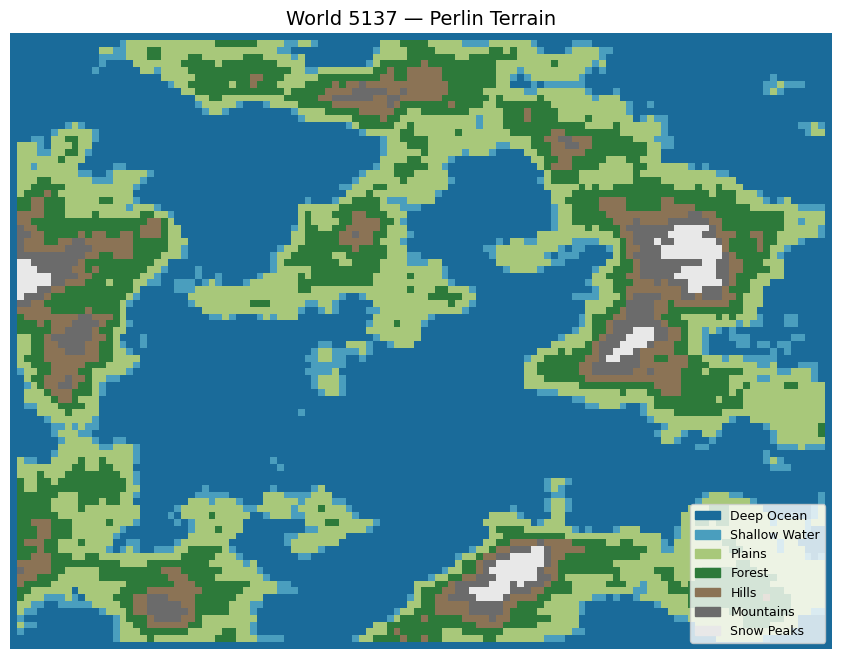

In [5]:
from noise import pnoise2

# === SETTINGS ===
SEED = 5137
WIDTH = 120
HEIGHT = 90
SCALE = 4.0
SEA_LEVEL = 0.0  # adjust to get more/less land

# === GENERATE ELEVATION VIA PERLIN ===
np.random.seed(SEED)
# Random offset so different seeds give different worlds
offset_x = np.random.randint(0, 10000)
offset_y = np.random.randint(0, 10000)

elevation = np.zeros((HEIGHT, WIDTH))
for y in range(HEIGHT):
    for x in range(WIDTH):
        elevation[y, x] = pnoise2(
            (x + offset_x) / WIDTH * SCALE,
            (y + offset_y) / HEIGHT * SCALE,
            octaves=6,
            persistence=0.5,
            lacunarity=2.0
        )

# === LAND/OCEAN MASK ===
world = (elevation > SEA_LEVEL).astype(int)
world[0, :] = world[-1, :] = world[:, 0] = world[:, -1] = 0
elevation[world == 0] = 0

# === NORMALISE LAND ELEVATION ===
land_mask = world == 1
e_min = elevation[land_mask].min()
e_max = elevation[land_mask].max()
elevation[land_mask] = (elevation[land_mask] - e_min) / (e_max - e_min)

# === TERRAIN CLASSIFICATION ===
thresholds = [
    (0.00, 0),  # deep ocean
    (0.05, 1),  # shallow water
    (0.25, 2),  # plains
    (0.45, 3),  # forest
    (0.60, 4),  # hills
    (0.75, 5),  # mountains
    (1.00, 6),  # snow peaks
]

terrain = np.zeros((HEIGHT, WIDTH), dtype=int)
for y in range(HEIGHT):
    for x in range(WIDTH):
        e = elevation[y, x]
        for threshold, zone in thresholds:
            if e <= threshold:
                terrain[y, x] = zone
                break

# === DRAW ===
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

colors = [
    '#1a6b9a',   # deep ocean
    '#4a9ebe',   # shallow water
    '#a8c87a',   # plains
    '#2d7a3a',   # forest
    '#8b7355',   # hills
    '#6b6b6b',   # mountains
    '#e8e8e8',   # snow peaks
]

cmap = mcolors.ListedColormap(colors)
plt.figure(figsize=(12, 8))
plt.imshow(terrain, cmap=cmap, vmin=0, vmax=6, interpolation='nearest')
plt.axis('off')
plt.title(f"World {SEED} — Perlin Terrain", fontsize=14)

labels = ['Deep Ocean', 'Shallow Water', 'Plains', 'Forest', 'Hills', 'Mountains', 'Snow Peaks']
patches = [mpatches.Patch(color=colors[i], label=labels[i]) for i in range(7)]
plt.legend(handles=patches, loc='lower right', fontsize=9)
plt.show()

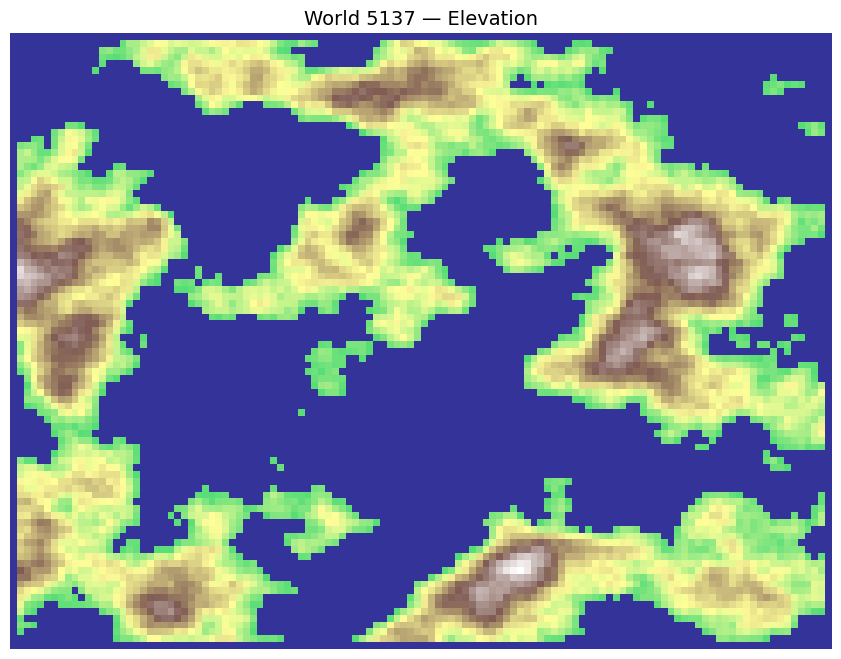

In [6]:
# Create a display version — ocean cells get a negative value
elevation_display = elevation.copy()
elevation_display[world == 0] = -0.5  # force ocean into blue zone

plt.figure(figsize=(12, 8))
plt.imshow(elevation_display, cmap='terrain', interpolation='nearest', vmin=-0.5, vmax=1.0)
plt.axis('off')
plt.title(f"World {SEED} — Elevation", fontsize=14)
plt.show()